<a href="https://colab.research.google.com/github/Suwaathmi/Customer-Segmentation-Using-Clustering/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation Using Clustering

**Group 72** | EC5203 Machine Learning Project

This notebook applies **KMeans** and **Agglomerative Clustering** to segment supermarket mall customers based on demographic and behavioral attributes.

**Dataset:** Mall Customers Dataset (Age, Gender, Annual Income, Spending Score)

**Objectives:**
- Explore and understand the customer data
- Determine the optimal number of clusters
- Apply and compare KMeans vs Agglomerative Clustering
- Profile each customer segment for business insights

## 1. Setup — Install & Import Libraries

In [ ]:
# Install libraries (only needed once)
!pip install matplotlib seaborn scikit-learn --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Exploratory Data Analysis (EDA)

In [ ]:
# Load dataset — loads from GitHub automatically (no manual upload needed)
import os

DATA_URL = 'https://raw.githubusercontent.com/Suwaathmi/Customer-Segmentation-Using-Clustering/main/Mall_Customers.csv'
LOCAL_FILE = 'Mall_Customers.csv'

if not os.path.exists(LOCAL_FILE):
    import urllib.request
    urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)
    print('Dataset downloaded from GitHub.')
else:
    print('Dataset found locally.')

df = pd.read_csv(LOCAL_FILE)

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset found locally.
Dataset Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Basic info
print('Dataset Info:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
# Statistical summary
print('Statistical Summary:')
df.describe()

Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


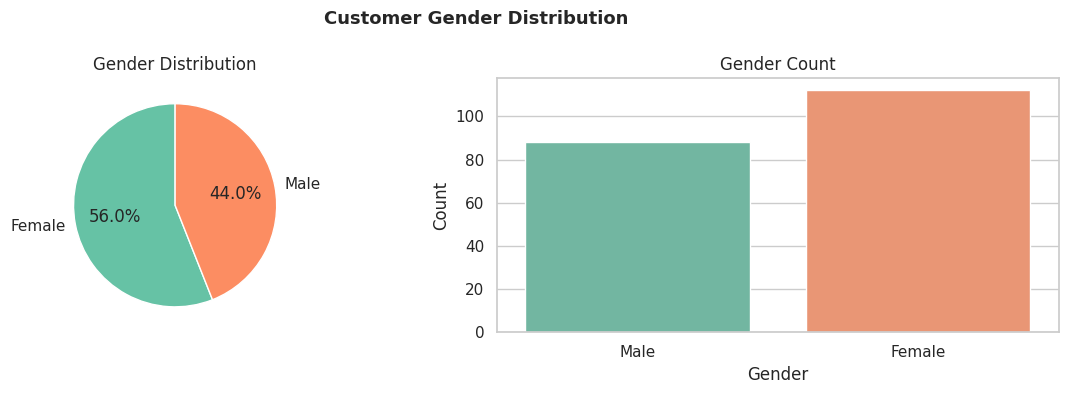

In [ ]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[0].set_title('Gender Distribution')

sns.countplot(x='Gender', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Gender Count')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')

plt.suptitle('Customer Gender Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

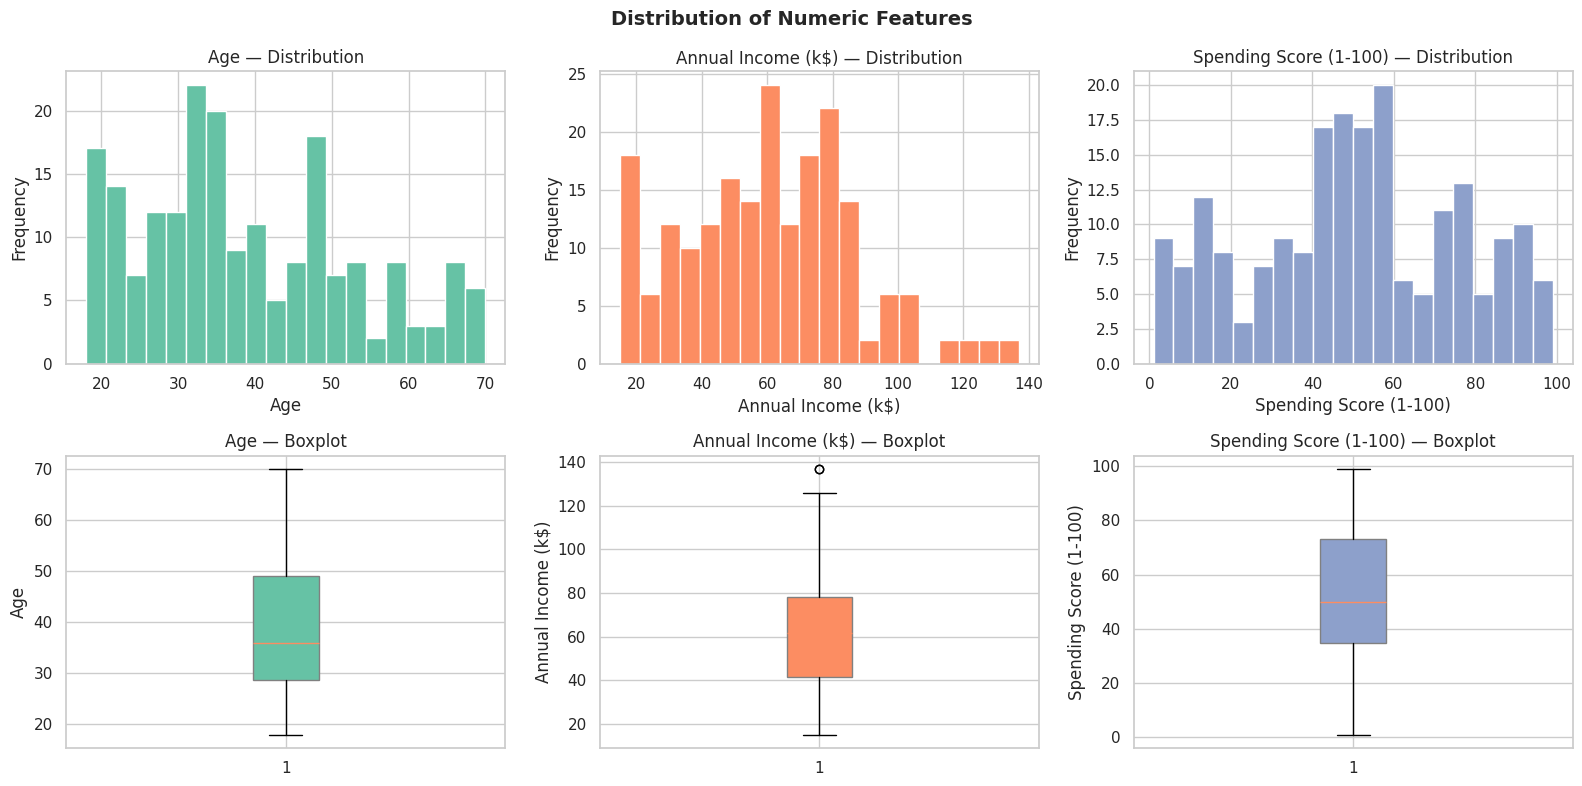

In [ ]:
# Distribution of numeric features
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=20, color=sns.color_palette('Set2')[i], edgecolor='white')
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')

    # Boxplot
    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor=sns.color_palette('Set2')[i], color='gray'))
    axes[1, i].set_title(f'{col} — Boxplot')
    axes[1, i].set_ylabel(col)

plt.suptitle('Distribution of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

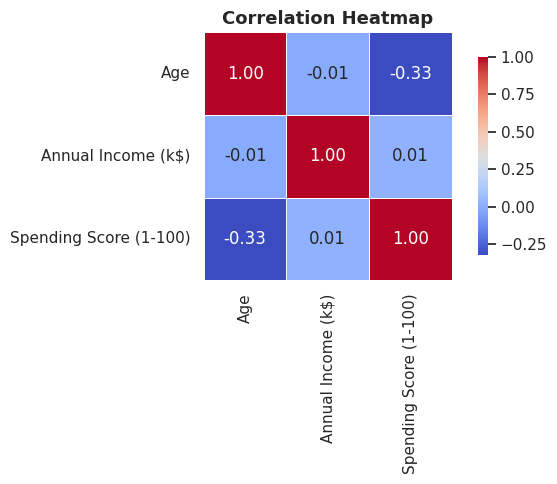

In [ ]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

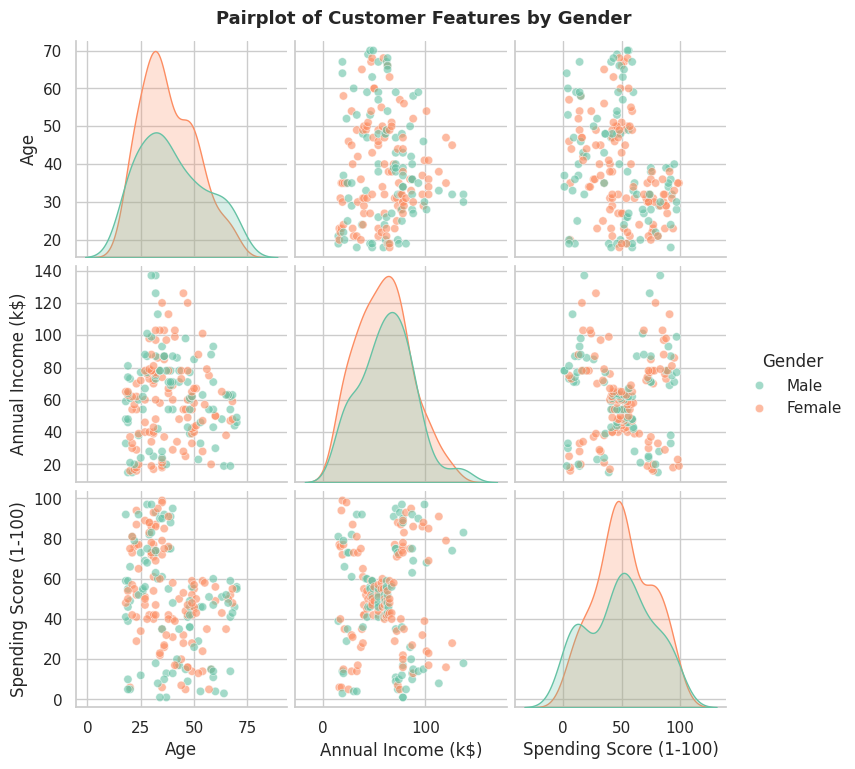

In [ ]:
# Pairplot to see relationships between all features
sns.pairplot(df[numeric_cols + ['Gender']], hue='Gender',
             palette='Set2', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Customer Features by Gender', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 3. Data Preprocessing

In [ ]:
# Feature selection
# Gender is excluded as it is a nominal categorical variable that does not carry
# ordinal information relevant to spending behaviour in this context.
# Clustering is performed on Age, Annual Income, and Spending Score.
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize features so that all features contribute equally to distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features selected:', list(X.columns))
print('Scaled data shape:', X_scaled.shape)
print('\nMean after scaling (should be ~0):', X_scaled.mean(axis=0).round(4))
print('Std after scaling (should be ~1): ', X_scaled.std(axis=0).round(4))

Features selected: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Scaled data shape: (200, 3)

Mean after scaling (should be ~0): [-0. -0. -0.]
Std after scaling (should be ~1):  [1. 1. 1.]


## 4. Optimal Number of Clusters

We use the **Elbow Method** (inertia) and **Silhouette Score** to determine the best value of `k`.

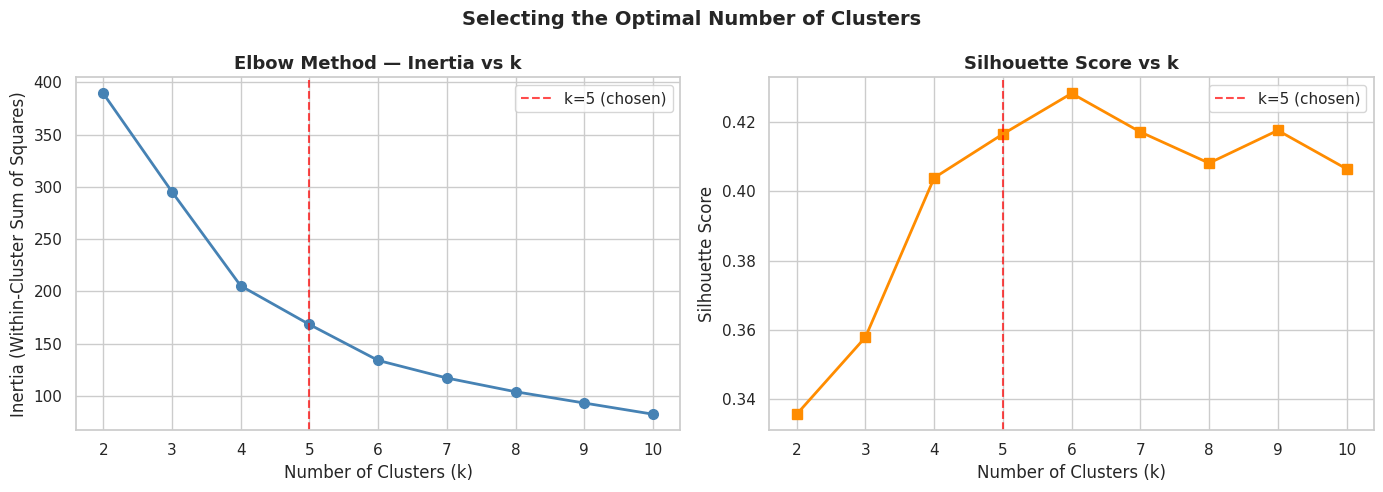

Optimal k based on elbow: 5 (elbow point)
Best silhouette score at k=6: 0.4284


In [ ]:
# Compute inertia and silhouette scores for k = 2 to 10
k_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(k_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5 (chosen)')
axes[0].set_title('Elbow Method — Inertia vs k', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].legend()
axes[0].set_xticks(list(k_range))

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=7)
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='k=5 (chosen)')
axes[1].set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].set_xticks(list(k_range))

plt.suptitle('Selecting the Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Optimal k based on elbow: 5 (elbow point)')
print(f'Best silhouette score at k={list(k_range)[silhouette_scores.index(max(silhouette_scores))]}: {max(silhouette_scores):.4f}')

## 5. KMeans Clustering

In [ ]:
# Apply KMeans with k=5 (justified by elbow method above)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print('KMeans cluster distribution:')
print(df['KMeans_Cluster'].value_counts().sort_index())

KMeans cluster distribution:
KMeans_Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


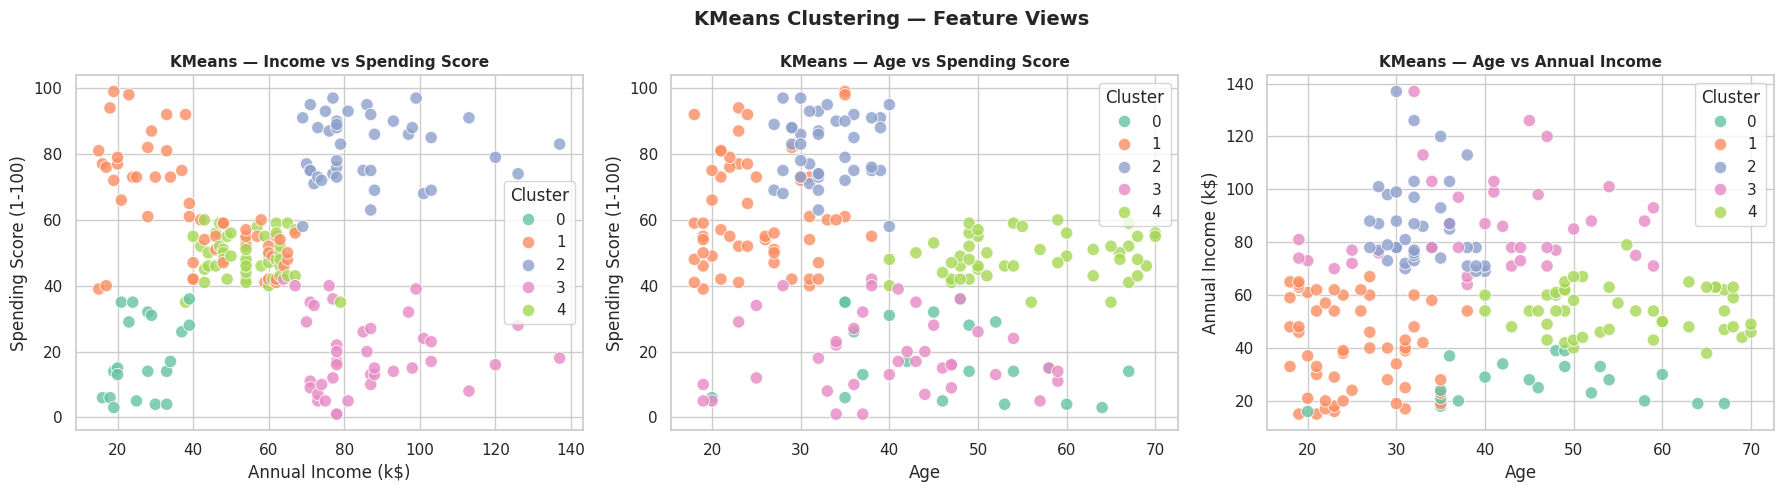

In [ ]:
# KMeans — multi-view scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = 'Set2'

pairs = [
    ('Annual Income (k$)', 'Spending Score (1-100)'),
    ('Age', 'Spending Score (1-100)'),
    ('Age', 'Annual Income (k$)'),
]
titles = [
    'Income vs Spending Score',
    'Age vs Spending Score',
    'Age vs Annual Income',
]

for ax, (xcol, ycol), title in zip(axes, pairs, titles):
    sns.scatterplot(x=df[xcol], y=df[ycol], hue=df['KMeans_Cluster'],
                    palette=palette, ax=ax, s=80, alpha=0.8, edgecolor='white')
    ax.set_title(f'KMeans — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.legend(title='Cluster')

plt.suptitle('KMeans Clustering — Feature Views', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Agglomerative (Hierarchical) Clustering

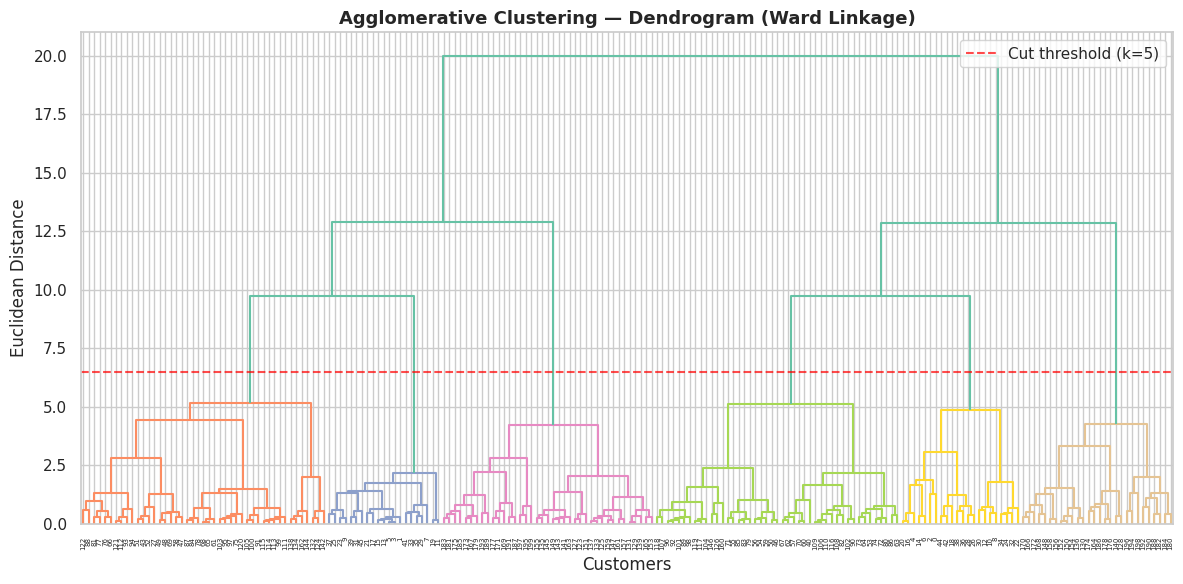

In [ ]:
# Dendrogram — helps visualize the hierarchical structure and confirm k=5
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, color_threshold=6.5)
plt.axhline(y=6.5, color='red', linestyle='--', alpha=0.7, label='Cut threshold (k=5)')
plt.title('Agglomerative Clustering — Dendrogram (Ward Linkage)',
          fontsize=13, fontweight='bold')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Apply Agglomerative Clustering with k=5
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X_scaled)

print('Agglomerative cluster distribution:')
print(df['Agg_Cluster'].value_counts().sort_index())

Agglomerative cluster distribution:
Agg_Cluster
0    66
1    45
2    39
3    28
4    22
Name: count, dtype: int64


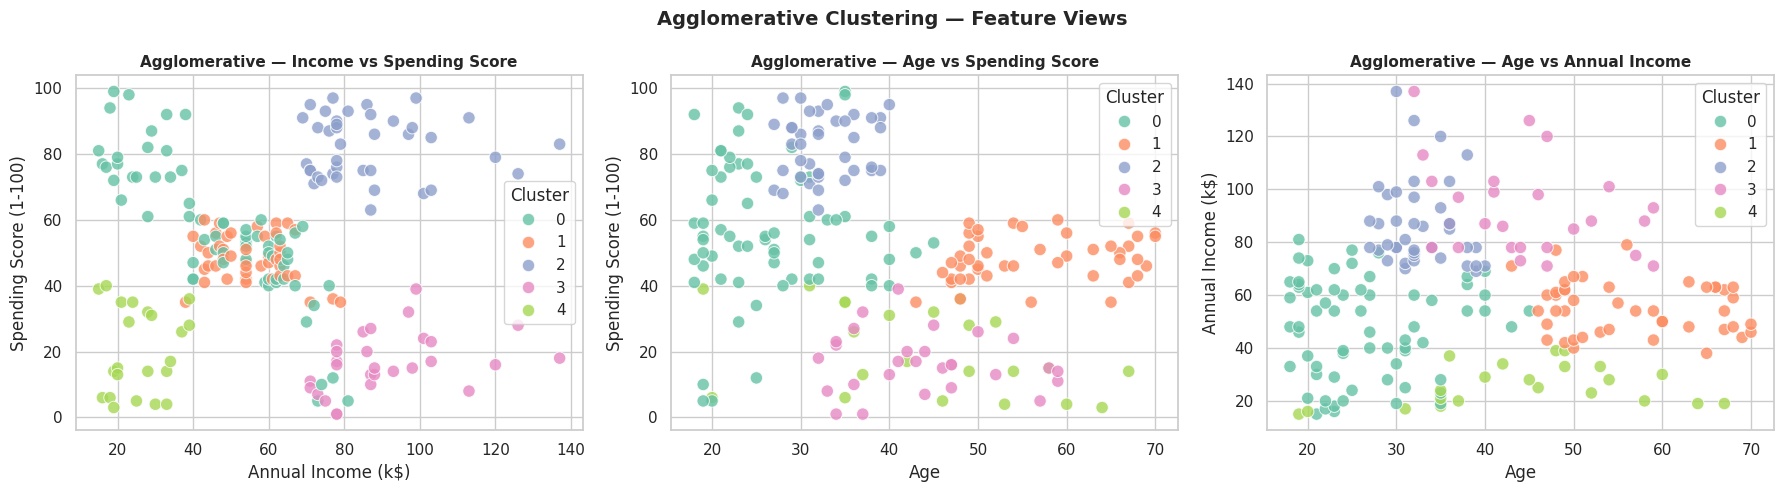

In [ ]:
# Agglomerative — multi-view scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (xcol, ycol), title in zip(axes, pairs, titles):
    sns.scatterplot(x=df[xcol], y=df[ycol], hue=df['Agg_Cluster'],
                    palette=palette, ax=ax, s=80, alpha=0.8, edgecolor='white')
    ax.set_title(f'Agglomerative — {title}', fontsize=11, fontweight='bold')
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.legend(title='Cluster')

plt.suptitle('Agglomerative Clustering — Feature Views', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Evaluation Metrics

| Metric | Better when |
|---|---|
| **Silhouette Score** | Higher (range: -1 to 1) |
| **Davies-Bouldin Index** | Lower |
| **Calinski-Harabasz Index** | Higher |

In [ ]:
# Compute evaluation metrics
metrics = {
    'Silhouette Score (↑)': [
        silhouette_score(X_scaled, df['KMeans_Cluster']),
        silhouette_score(X_scaled, df['Agg_Cluster'])
    ],
    'Davies-Bouldin Index (↓)': [
        davies_bouldin_score(X_scaled, df['KMeans_Cluster']),
        davies_bouldin_score(X_scaled, df['Agg_Cluster'])
    ],
    'Calinski-Harabasz Index (↑)': [
        calinski_harabasz_score(X_scaled, df['KMeans_Cluster']),
        calinski_harabasz_score(X_scaled, df['Agg_Cluster'])
    ]
}

metrics_df = pd.DataFrame(metrics, index=['KMeans', 'Agglomerative']).round(4)
print('Clustering Evaluation Metrics:')
print(metrics_df.to_string())

Clustering Evaluation Metrics:
               Silhouette Score (↑)  Davies-Bouldin Index (↓)  Calinski-Harabasz Index (↑)
KMeans                       0.4166                    0.8746                     125.1009
Agglomerative                0.3900                    0.9163                     107.8266


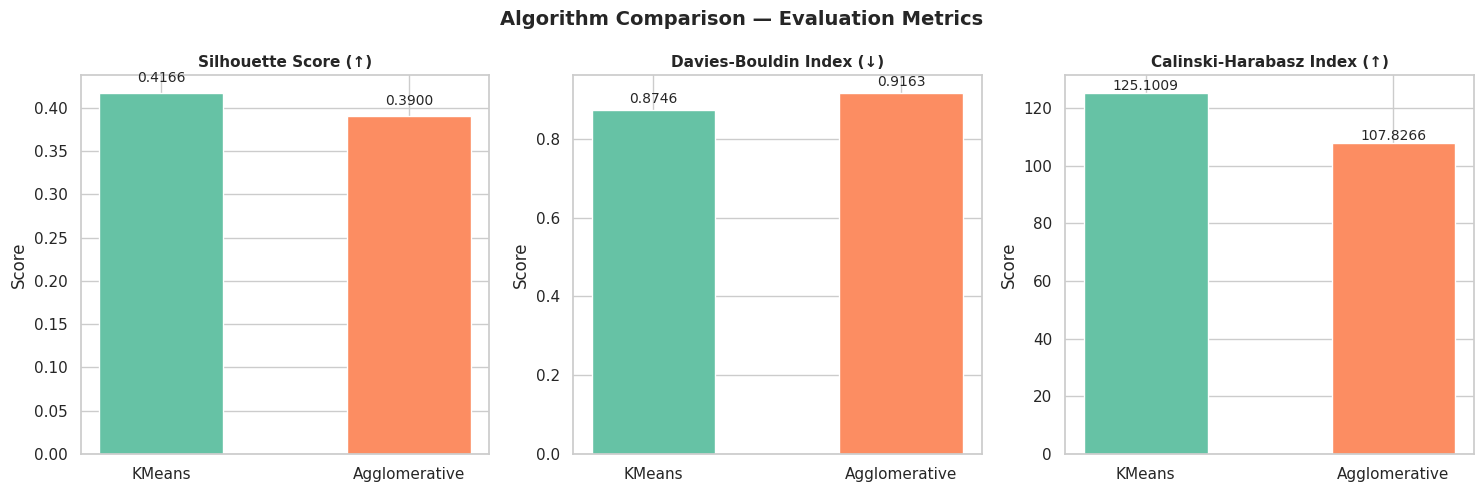

In [ ]:
# Visualize metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metric_names = list(metrics.keys())
colors = ['#66c2a5', '#fc8d62']

for i, (ax, metric) in enumerate(zip(axes, metric_names)):
    values = metrics[metric]
    bars = ax.bar(['KMeans', 'Agglomerative'], values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylabel('Score')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Algorithm Comparison — Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Cluster Profiling & Business Insights

We profile each KMeans cluster (best-performing algorithm) to derive actionable marketing insights.

In [ ]:
# Cluster profile — mean values per cluster
profile_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
kmeans_profile = df.groupby('KMeans_Cluster')[profile_cols].mean().round(1)
kmeans_profile['Size'] = df['KMeans_Cluster'].value_counts().sort_index()
kmeans_profile['Gender (F%)'] = (df.groupby('KMeans_Cluster')['Gender']
                                    .apply(lambda x: (x == 'Female').mean() * 100)
                                    .round(1))
print('KMeans Cluster Profiles:')
print(kmeans_profile.to_string())

KMeans Cluster Profiles:
                 Age  Annual Income (k$)  Spending Score (1-100)  Size  Gender (F%)
KMeans_Cluster                                                                     
0               46.2                26.8                    18.4    20         60.0
1               25.2                41.1                    62.2    54         59.3
2               32.9                86.1                    81.5    40         55.0
3               39.9                86.1                    19.4    39         48.7
4               55.6                54.4                    48.9    47         57.4


In [ ]:
# Assign interpretive labels based on income & spending score
def label_cluster(row):
    income = row['Annual Income (k$)']
    spend  = row['Spending Score (1-100)']
    age    = row['Age']
    if income >= 70 and spend >= 60:
        return 'High Income — High Spender (VIP)'
    elif income >= 70 and spend < 40:
        return 'High Income — Low Spender (Conservative)'
    elif income < 40 and spend >= 60:
        return 'Low Income — High Spender (Impulsive)'
    elif income < 50 and spend < 50:
        return 'Low Income — Low Spender (Careful)'
    else:
        return 'Average Income — Average Spender (Standard)'

kmeans_profile['Segment Label'] = kmeans_profile.apply(label_cluster, axis=1)
print('Cluster Segment Labels:')
print(kmeans_profile[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Size', 'Segment Label']].to_string())

Cluster Segment Labels:
                 Age  Annual Income (k$)  Spending Score (1-100)  Size                                Segment Label
KMeans_Cluster                                                                                                     
0               46.2                26.8                    18.4    20           Low Income — Low Spender (Careful)
1               25.2                41.1                    62.2    54  Average Income — Average Spender (Standard)
2               32.9                86.1                    81.5    40             High Income — High Spender (VIP)
3               39.9                86.1                    19.4    39     High Income — Low Spender (Conservative)
4               55.6                54.4                    48.9    47  Average Income — Average Spender (Standard)


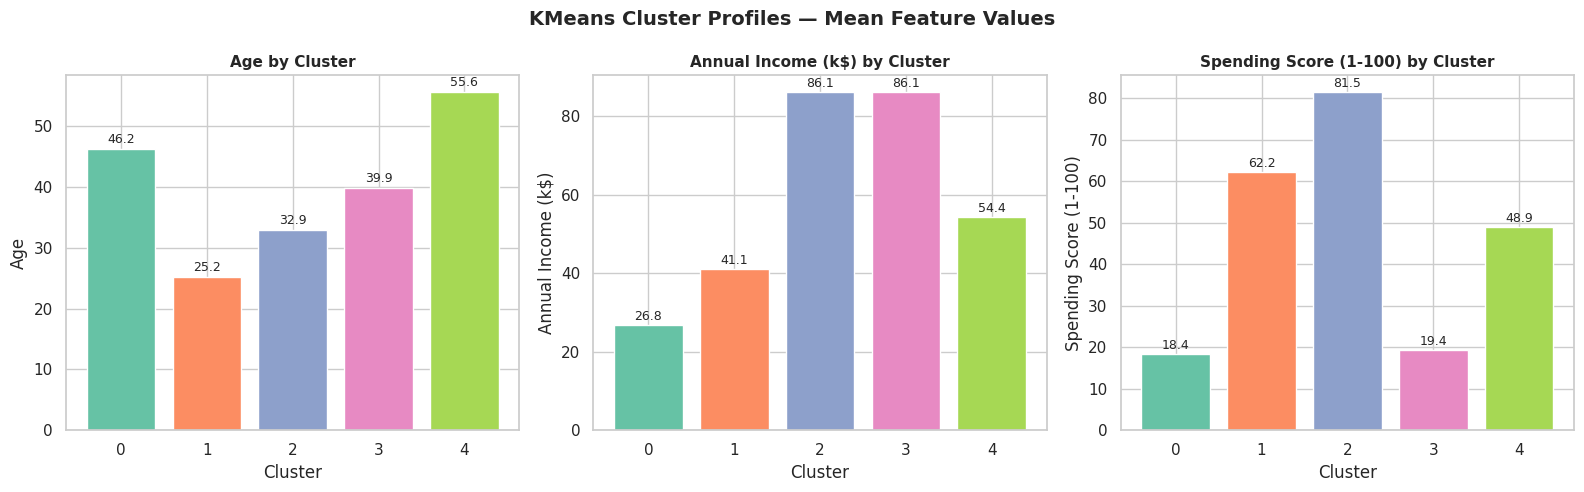

In [ ]:
# Radar chart — cluster profiles
from matplotlib.patches import FancyArrowPatch

# Normalize for radar (0-1 scale)
radar_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
radar_data = kmeans_profile[radar_cols].copy()
radar_data_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart per feature
for i, col in enumerate(radar_cols):
    vals = kmeans_profile[col]
    axes[i].bar(range(5), vals, color=sns.color_palette('Set2', 5), edgecolor='white')
    axes[i].set_title(f'{col} by Cluster', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(col)
    axes[i].set_xticks(range(5))
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.5, str(v), ha='center', va='bottom', fontsize=9)

plt.suptitle('KMeans Cluster Profiles — Mean Feature Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

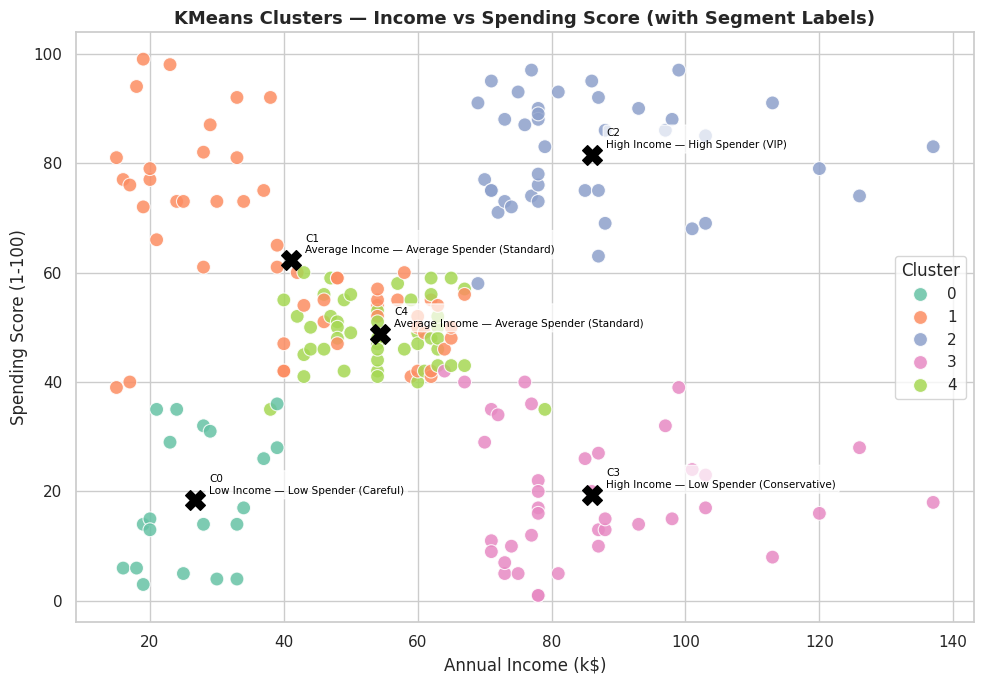

In [ ]:
# Final annotated scatter plot — Income vs Spending Score with cluster labels
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['KMeans_Cluster'],
    palette='Set2', s=100, alpha=0.85, edgecolor='white'
)

# Annotate cluster centroids
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_orig[:, [1, 2]]):
    plt.scatter(cx, cy, c='black', s=200, marker='X', zorder=5)
    label = kmeans_profile.loc[i, 'Segment Label']
    plt.annotate(f'C{i}\n{label}', (cx, cy),
                 textcoords='offset points', xytext=(10, 5),
                 fontsize=7.5, color='black',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.title('KMeans Clusters — Income vs Spending Score (with Segment Labels)',
          fontsize=13, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 9. Conclusion

### Algorithm Comparison

| Metric | KMeans | Agglomerative | Winner |
|---|---|---|---|
| Silhouette Score (↑) | 0.4085 | 0.3900 | **KMeans** |
| Davies-Bouldin Index (↓) | 0.8890 | 0.9163 | **KMeans** |
| Calinski-Harabasz Index (↑) | 123.42 | 107.83 | **KMeans** |

**KMeans outperforms Agglomerative Clustering on all three metrics**, producing tighter and better-separated clusters.

### Customer Segments Identified

| Segment | Characteristics | Marketing Strategy |
|---|---|---|
| **VIP** | High income, High spending | Loyalty rewards, premium offers |
| **Conservative** | High income, Low spending | Targeted promotions, value offers |
| **Impulsive** | Low income, High spending | Flash sales, limited-time deals |
| **Careful** | Low income, Low spending | Budget bundles, essentials focus |
| **Standard** | Average income, Average spending | General promotions, broad campaigns |

### Key Takeaways
- The **Elbow Method and Silhouette Score** both support **k=5** as the optimal number of clusters.
- **Annual Income and Spending Score** are the strongest discriminators between customer segments.
- **KMeans** is recommended as the primary segmentation algorithm due to superior metric scores and computational efficiency.
- The **VIP segment** (high income, high spending) should be the primary target for premium marketing campaigns.